In [1]:
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LogNorm
import numpy as np
from ocnus_py import COREWLEnsbl, COREWLModel, Univariate, CovMatrix, ImageObser, ScObs, CORERHOEnsbl, CORERHOModel, Obser
from scipy.ndimage import gaussian_filter
import matplotlib.animation as animation
from IPython.display import HTML

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.WARNING)

plt.style.use('dark_background')

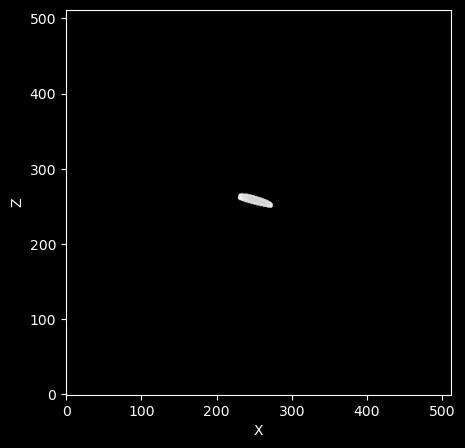

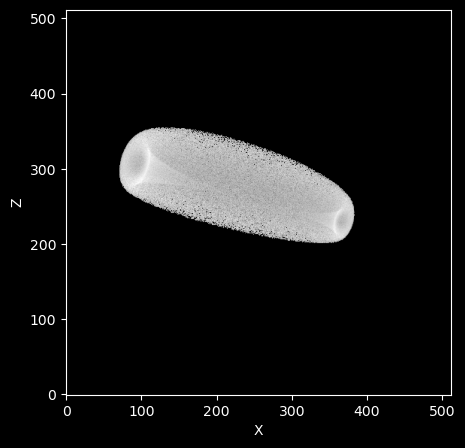

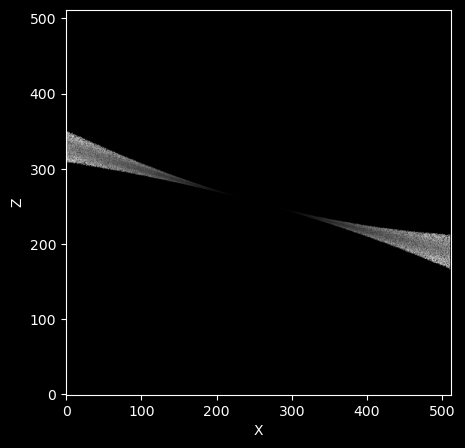

In [2]:
# Set up model priors
model = COREWLModel([
    Univariate.uniform("longitude", -1.0, 1.0),
    Univariate.uniform("latitude", -0.25, 0.25),
    Univariate.uniform("inclination", -3.5, 3.14),
    Univariate.constant("distance_0", 20.0),
    Univariate.uniform("diameter_1au", 0.05, 0.35),
    Univariate.uniform("delta", 0.5, 1.0),
    Univariate.uniform("velocity", 700.0, 1500.0),
    Univariate.uniform("b_scale", 10.0, 30.0),
    Univariate.uniform("tau", -50.0, 0.0),
    Univariate.constant("sw_velocity", 400.0),
    Univariate.constant("sw_gamma", 1.0),
])

params = np.array([
    np.deg2rad(-10.0),   # longitude
    np.deg2rad(5.0),  # latitude
    np.deg2rad(-15.0),    # inclination
    20.0, 
    0.3,                # diameter (real width is multiplied by delta)
    0.5,                # delta in (0, 1]
    800.0, 
    25.0, 
    -50, 
    400.0, 
    1.0
])

scobs = ScObs(
    [3600 * i for i in range(5 * 24)],
    [[1.0, 0.0, 0.0] for _ in range(5 * 24)]
)

# single particle ensemble for generating the output
ensbl = COREWLEnsbl(1)
ensbl.set_particle(0, params)
obser = ImageObser(scobs, 1)
model.wl_simulate(ensbl, obser)

plt.figure(figsize=(5, 5))
plt.imshow(np.log10(obser[0][0] + 1), cmap='gist_gray', origin='lower')
plt.xlabel("X")
plt.ylabel("Z")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(np.log10(obser[0][30] + 1), cmap='gist_gray', origin='lower')
plt.xlabel("X")
plt.ylabel("Z")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(np.log10(obser[0][119] + 1), cmap='gist_gray', origin='lower')
plt.xlabel("X")
plt.ylabel("Z")
plt.show()

In [3]:
if False:
    fig, ax = plt.subplots(1, 1)

    img = ax.imshow(np.log10(obser[0][60] + 1), cmap='gist_gray', vmax=np.log10(np.max(obser[0][0])), origin='lower')
    ax.set_xlabel("X")
    ax.set_ylabel("Z")
    plt.close()

    def update(frame):
        img.set_data(np.log10(obser[0][frame] + 1))

    ani = animation.FuncAnimation(fig=fig, func=update, frames=120, interval=30)

    HTML(ani.to_jshtml())


In [ ]:
# Generate BOX
Nx = 256
g = np.linspace(-1, 1, Nx)
xx, yy, zz = mgrid = np.meshgrid(g, g, g)
Nt = Nx**3

gscobs = ScObs(
    [3600.0 * 60 for _ in range(Nt)],
    [[xx.ravel()[i], yy.ravel()[i], zz.ravel()[i]] for i in range(Nt)]
)

model_rho = CORERHOModel([
    Univariate.uniform("longitude", -1.0, 1.0),
    Univariate.uniform("latitude", -0.25, 0.25),
    Univariate.uniform("inclination", -3.5, 3.14),
    Univariate.constant("distance_0", 20.0),
    Univariate.uniform("diameter_1au", 0.05, 0.35),
    Univariate.uniform("delta", 0.5, 1.0),
    Univariate.uniform("velocity", 700.0, 1500.0),
    Univariate.uniform("b_scale", 10.0, 30.0),
    Univariate.uniform("tau", -50.0, 0.0),
    Univariate.constant("sw_velocity", 400.0),
    Univariate.constant("sw_gamma", 1.0),
])

# single particle ensemble for generating the output
ensbl = CORERHOEnsbl(1)
ensbl.set_particle(0, params)
obser = Obser(gscobs, 1)
model_rho.rho_simulate(ensbl, obser)

box = obser[0].reshape(Nx, Nx, Nx)

In [8]:
np.save("grid.dat", box)